# RQ2 — Priority alignment và robustness

Notebook test khóa trên candidate v4.1.0. Oracle incident grouping chỉ xuất hiện trong evaluator; mọi phương pháp xếp hạng chỉ nhận báo cáo quan sát. Kết quả synthetic/illustrative, không phải chính sách cứu hộ đã được chuyên gia thực địa xác nhận.

In [1]:
# Cài đúng các gói cần thiết nhưng KHÔNG hạ/pin NumPy của Colab.
%pip install -q python-louvain scipy scikit-learn pandas matplotlib

import os, sys, json, hashlib, shutil, zipfile, platform, importlib.metadata
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/data')
    WORK_DIR = Path('/content/rq_candidate_v4')
else:
    DATA_DIR = Path.cwd()
    WORK_DIR = Path('/tmp/rq_candidate_v4')
DATA_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

def locate_repo():
    # Local execution (for verification) or an already extracted Colab tree.
    candidates = [Path.cwd(), Path.cwd() / 'nckh2-main', WORK_DIR / 'source']
    for base in candidates:
        if (base / 'demo/data/generate.py').exists():
            return base.resolve()
    zips = sorted(p for p in DATA_DIR.glob('*.zip') if p.name != 'candidate_v4_locked.zip')
    if not zips:
        raise FileNotFoundError(
            'Không thấy source zip trong MyDrive/Colab Notebooks/data. '
            'Hãy upload zip chứa thư mục demo/ rồi chạy lại.'
        )
    extract = WORK_DIR / 'source'
    for source_zip in zips:
        if extract.exists():
            shutil.rmtree(extract)
        extract.mkdir(parents=True)
        with zipfile.ZipFile(source_zip) as archive:
            archive.extractall(extract)
        matches = sorted(extract.rglob('demo/data/generate.py'))
        if matches:
            print('Source zip:', source_zip.name)
            return matches[0].parents[2].resolve()
    raise RuntimeError('Không zip nào trong data chứa demo/data/generate.py')

REPO = locate_repo()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
print('Source repo:', REPO)

Mounted at /content/drive
Source zip: nckh2-main (2).zip
Source repo: /content/rq_candidate_v4/source/nckh2-main (2)/nckh2-main


In [2]:
from demo.data.generate import write_candidate_bundle
from demo.data.schema import GENERATOR_VERSION, FORBIDDEN_INFERENCE_FIELDS, observable_report

CACHE_ZIP = DATA_DIR / 'candidate_v4_locked.zip'
CACHE_SHA = DATA_DIR / 'candidate_v4_locked.sha256'
CACHE_DIR = WORK_DIR / 'candidate_v4_locked'

def deterministic_zip(source_dir, target_zip):
    # Fixed timestamp/order makes the archive hash reproducible.
    tmp = target_zip.with_suffix('.partial.zip')
    with zipfile.ZipFile(tmp, 'w', compression=zipfile.ZIP_DEFLATED, compresslevel=9) as zf:
        for path in sorted(source_dir.rglob('*')):
            if not path.is_file():
                continue
            rel = path.relative_to(source_dir).as_posix()
            info = zipfile.ZipInfo(rel, date_time=(2026, 1, 1, 0, 0, 0))
            info.compress_type = zipfile.ZIP_DEFLATED
            info.external_attr = 0o644 << 16
            zf.writestr(info, path.read_bytes())
    tmp.replace(target_zip)

def verify_or_create_cache(allow_create=True):
    if CACHE_ZIP.exists():
        actual = sha256_file(CACHE_ZIP)
        if not CACHE_SHA.exists():
            raise RuntimeError('Có candidate_v4_locked.zip nhưng thiếu file .sha256; từ chối dùng cache không xác thực.')
        expected = CACHE_SHA.read_text().strip()
        if actual != expected:
            raise RuntimeError(f'Hash candidate cache sai: expected={expected}, actual={actual}')
    else:
        if not allow_create:
            raise FileNotFoundError('Chưa có candidate_v4_locked.zip; hãy chạy notebook RQ2 trước.')
        build_dir = WORK_DIR / 'candidate_build'
        if build_dir.exists():
            shutil.rmtree(build_dir)
        manifest = write_candidate_bundle(build_dir)
        assert manifest['generator_version'] == GENERATOR_VERSION
        assert len(manifest['entries']) == 80
        deterministic_zip(build_dir, CACHE_ZIP)
        CACHE_SHA.write_text(sha256_file(CACHE_ZIP) + '\n')
    actual = sha256_file(CACHE_ZIP)
    if CACHE_DIR.exists():
        shutil.rmtree(CACHE_DIR)
    CACHE_DIR.mkdir(parents=True)
    with zipfile.ZipFile(CACHE_ZIP) as zf:
        zf.extractall(CACHE_DIR)
    manifest = json.loads((CACHE_DIR / 'manifest.json').read_text())
    mapping = manifest['seed_mapping']
    assert {k: len(v) for k, v in mapping.items()} == {'development': 20, 'calibration': 20, 'test': 40}
    all_seeds = sum((list(v) for v in mapping.values()), [])
    assert len(all_seeds) == len(set(all_seeds)) == 80
    assert all(row['quality_status'] == 'pass' for row in manifest['entries'])
    return manifest, actual

MANIFEST, BUNDLE_SHA256 = verify_or_create_cache(allow_create=True)
print('Candidate:', MANIFEST['generator_version'], '80 runs; SHA256:', BUNDLE_SHA256)

Candidate: 4.1.0 80 runs; SHA256: a7c7a3f7ea63e57f1d98bd42f21c02aa04a69eaa37c824584a2be65f00f2d7e1


## Định nghĩa và kiểm thử

Relevance độc lập là $B_k=H_k(480)-H_k(0)$. `random` là trung bình của 100 permutation cố định; mọi trường evaluator-only được kiểm tra không rò vào inference.

In [3]:
import math, copy, warnings
from dataclasses import replace
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import ndcg_score

from demo.data.generate import candidate_inference_events, load_candidate_dataset
from demo.pipeline.attributes import compute_confidence
from demo.pipeline.config import DEFAULT_CONFIG
from demo.pipeline.priority import (
    score_clusters, REVISED_ESTIMATOR_NAME, LEGACY_ESTIMATOR_NAME,
    observable_report_fingerprint, are_near_duplicate_reports,
)
from demo.experiments.exp16_priority_robustness import (
    evaluate_loaded_priority_seed, _incident_maps, _group_operational_events,
    _copy_groups, _score_bundle, _evaluate_scenario,
)
from demo.experiments.inference import descriptive_summary, paired_comparison, apply_holm

METHODS = ('duplicate_aware_robust', 'legacy_raw', 'simple_linear',
           'urgency_only', 'population_only', 'random')
ALIGN_DIRECTIONS = {'ndcg_at_5':'higher', 'spearman':'higher', 'top5_overlap':'higher'}
ROBUST_DIRECTIONS = {
    'priority_drift_abs_normalized':'lower', 'mean_rank_drift_normalized':'lower',
    'top_k_churn':'lower', 'false_priority_lift_normalized':'lower',
    'n_error_relative_after':'lower', 'v_error_relative_after':'lower',
}

def latent_harm(incident, response_min):
    curve = incident['harm_curve']
    completion = float(response_min) + float(incident['service_demand_min'])
    late = max(0.0, completion - float(incident['deadline_min']) - float(curve['grace_min']))
    # Capacity term is time-independent; it is included in H and cancels in B.
    overload = max(0.0, float(incident['service_demand_min']) - 34.0)
    return float(curve['slope']) * late + float(curve['capacity_penalty']) * overload

def independent_benefit(incident):
    return max(0.0, latent_harm(incident, 480.0) - latent_harm(incident, 0.0))

def oracle_groups(data, events):
    by_id = {str(e.event_id): e for e in events}
    groups = defaultdict(list)
    for report in data['reports']:
        iid = report['evaluation_only']['incident_id']
        if iid is not None:
            groups[str(iid)].append(by_id[str(report['event_id'])])
    return {k: sorted(v, key=lambda e: str(e.event_id)) for k, v in sorted(groups.items())}

def method_scores(data, events, seed):
    groups = oracle_groups(data, events)
    incidents = {str(x['incident_id']): x for x in data['incidents']}
    flat, labels, label_to_iid = [], [], {}
    for label, iid in enumerate(sorted(groups)):
        label_to_iid[label] = iid
        flat.extend(groups[iid]); labels.extend([label] * len(groups[iid]))
    compute_confidence(flat, DEFAULT_CONFIG.confidence)
    scores = {}
    for estimator in (REVISED_ESTIMATOR_NAME, LEGACY_ESTIMATOR_NAME):
        scored = score_clusters(flat, labels, DEFAULT_CONFIG.priority, estimator=estimator)
        scores[estimator] = {label_to_iid[int(s.cluster_id)]: float(s.priority) for s in scored}
    denom = math.log1p(DEFAULT_CONFIG.priority.n_ref)
    scores['simple_linear'], scores['urgency_only'], scores['population_only'] = {}, {}, {}
    for iid, members in groups.items():
        urgency = float(np.mean([e.urgency for e in members]))
        flood = float(np.mean([e.flood for e in members]))
        population = min(1.0, math.log1p(sum(max(0, e.n_trapped) for e in members)) / denom)
        scores['simple_linear'][iid] = (urgency + flood + population) / 3.0
        scores['urgency_only'][iid] = urgency
        scores['population_only'][iid] = population
    # Mean of 100 fixed permutations = deterministic random-ranking baseline.
    ids = sorted(groups)
    accumulator = {iid: 0.0 for iid in ids}
    for repetition in range(100):
        rng = np.random.default_rng(seed * 1000 + repetition)
        for rank, index in enumerate(rng.permutation(len(ids))):
            accumulator[ids[int(index)]] += (len(ids) - rank) / len(ids)
    scores['random'] = {iid: value / 100.0 for iid, value in accumulator.items()}
    return scores, incidents, groups

def alignment_rows_for_seed(data, events, source_sha):
    seed = int(data['seed'])
    scores, incidents, _ = method_scores(data, events, seed)
    ids = sorted(incidents)
    relevance = np.array([independent_benefit(incidents[iid]) for iid in ids], dtype=float)
    true_top = set(np.array(ids)[np.argsort(-relevance, kind='stable')[:min(5, len(ids))]])
    rows = []
    for method in METHODS:
        predicted = np.array([scores[method][iid] for iid in ids], dtype=float)
        k = min(5, len(ids))
        pred_top = set(np.array(ids)[np.argsort(-predicted, kind='stable')[:k]])
        rho = spearmanr(predicted, relevance).statistic
        rows.append({
            'seed': seed, 'stage': 'test', 'method': method,
            'ndcg_at_5': float(ndcg_score([relevance], [predicted], k=k)),
            'spearman': 0.0 if not np.isfinite(rho) else float(rho),
            'top5_overlap': len(true_top & pred_top) / k,
            'n_incidents': len(ids), 'dataset_source_sha256': source_sha,
        })
    return rows

def contradiction_rows(data, events, source_sha):
    by_id = {str(e.event_id): e for e in events}
    incidents, by_gt = _incident_maps(data)
    _, clean = _group_operational_events(data, by_id)
    target = min(clean)
    anchor = min(clean[target], key=lambda e: str(e.event_id))
    attacks = [
        replace(anchor, event_id=f'{anchor.event_id}-contra-hiF', flood=1.0, urgency=0.0),
        replace(anchor, event_id=f'{anchor.event_id}-contra-hiE', flood=0.0, urgency=1.0),
    ]
    attacked = _copy_groups(clean); attacked[target].extend(attacks)
    rows = _evaluate_scenario(
        seed=int(data['seed']), stage='test', scenario='contradictory_F_E',
        target_incident_id=target, before_groups=clean, after_groups=attacked,
        incidents=incidents, incidents_by_gt=by_gt, attack_events=attacks,
        before_bundle=_score_bundle(clean, incidents, by_gt),
        metadata={'construction':'two synthetic reports: (F,E)=(1,0) and (0,1)'},
    )
    for row in rows: row['dataset_source_sha256'] = source_sha
    return rows

def unit_tests():
    data_path = CACHE_DIR / 'development/seed_1000.json'
    data = load_candidate_dataset(data_path); events = candidate_inference_events(data)
    assert all(e.gt_cluster == -1 and e.is_fake is False for e in events)
    for report in data['reports']:
        assert not (set(observable_report(report)) & FORBIDDEN_INFERENCE_FIELDS)
    anchor = events[0]
    exact = replace(anchor, event_id='unit-exact')
    compute_confidence([anchor, exact], DEFAULT_CONFIG.confidence)
    assert observable_report_fingerprint(anchor) == observable_report_fingerprint(exact)
    labels = [0, 0]
    revised = score_clusters([anchor, exact], labels, DEFAULT_CONFIG.priority, estimator=REVISED_ESTIMATOR_NAME)[0]
    single = score_clusters([anchor], [0], DEFAULT_CONFIG.priority, estimator=REVISED_ESTIMATOR_NAME)[0]
    assert np.isclose(revised.priority, single.priority)
    near = replace(anchor, event_id='unit-near', lat=anchor.lat + 1e-6)
    compute_confidence([anchor, near], DEFAULT_CONFIG.confidence)
    assert are_near_duplicate_reports(anchor, near)
    assert method_scores(data, candidate_inference_events(data), 1000)[0]['random'] == method_scores(data, candidate_inference_events(data), 1000)[0]['random']
    print('PASS RQ2 unit tests: leakage, exact invariance, near-boundary, deterministic random.')

unit_tests()

PASS RQ2 unit tests: leakage, exact invariance, near-boundary, deterministic random.


## Chạy đúng 40 test seed và xuất artifact

Cell này có thể mất vài phút. CI là deterministic bootstrap 95%; so sánh ghép cặp dùng Wilcoxon và Holm trong từng family.

RQ2: 5/40 test runs
RQ2: 10/40 test runs
RQ2: 15/40 test runs
RQ2: 20/40 test runs
RQ2: 25/40 test runs
RQ2: 30/40 test runs
RQ2: 35/40 test runs
RQ2: 40/40 test runs


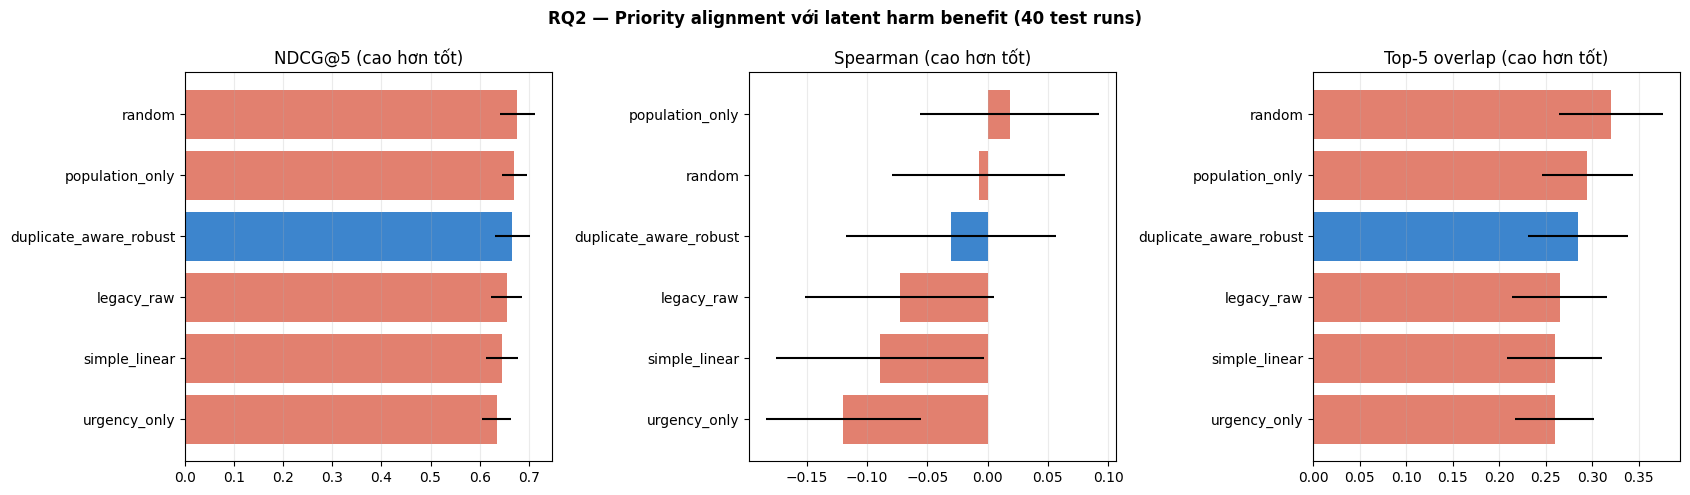

CSV SHA256 (chạy lại cùng code/seed phải giống): {'rq2_paired_comparisons.csv': 'ea1590f2af28cfa98600a165c83b4899208460e95efc0738ec8e979d1e6f1fd3', 'rq2_rank_alignment_test.csv': 'becf8f619254d4afb15a8f93874d6dd077e7fa696990dae72decad9ecd6f3dae', 'rq2_robustness_test.csv': '9e74cb7f89008471a4263237878efa0162a007e7c3ac8a274dd896842578f430', 'rq2_summary.csv': 'e2b5d6ccdf2e53291476ea8307a73ac9876d05038f88bcc203d655813b67296b'}
Đã lưu: /content/drive/MyDrive/Colab Notebooks/data/rq2_results


,section,method,scenario,metric,direction,mean,paired_confidence_interval
0,alignment,duplicate_aware_robust,all_test,ndcg_at_5,higher,0.666890,"[0.630573585791977, 0.7018339735459405]"
1,alignment,duplicate_aware_robust,all_test,spearman,higher,-0.030368,"[-0.1164705882352941, 0.054935661764705754]"
2,alignment,duplicate_aware_robust,all_test,top5_overlap,higher,0.285000,"[0.2348750000000005, 0.34]"
3,alignment,legacy_raw,all_test,ndcg_at_5,higher,0.654771,"[0.6228742253092528, 0.6849560580617219]"
4,alignment,legacy_raw,all_test,spearman,higher,-0.072868,"[-0.14934007352941175, 0.0026525735294116756]"
5,alignment,legacy_raw,all_test,top5_overlap,higher,0.265000,"[0.215, 0.31500000000000006]"
6,alignment,population_only,all_test,ndcg_at_5,higher,0.670938,"[0.6471053904027629, 0.6954605383428879]"
7,alignment,population_only,all_test,spearman,higher,0.018433,"[-0.05368869827261033, 0.09018360382835185]"
8,alignment,population_only,all_test,top5_overlap,higher,0.295000,"[0.24500000000000002, 0.34]"
9,alignment,random,all_test,ndcg_at_5,higher,0.676322,"[0.6405248169558695, 0.7099514476359288]"


In [4]:
alignment_rows, robustness_rows = [], []
for position, seed in enumerate(MANIFEST['seed_mapping']['test'], 1):
    path = CACHE_DIR / f'test/seed_{seed}.json'
    source_sha = sha256_file(path)
    data = load_candidate_dataset(path)
    events = candidate_inference_events(data)
    alignment_rows.extend(alignment_rows_for_seed(data, events, source_sha))
    robustness_rows.extend(evaluate_loaded_priority_seed(
        seed=seed, stage='test', inference_events=events,
        evaluator_data=data, source_sha256=source_sha,
    ))
    robustness_rows.extend(contradiction_rows(data, candidate_inference_events(data), source_sha))
    if position % 5 == 0: print(f'RQ2: {position}/40 test runs')

alignment = pd.DataFrame(alignment_rows)
robustness = pd.DataFrame(robustness_rows)
assert len(alignment) == 40 * len(METHODS)
assert set(alignment.seed) == set(MANIFEST['seed_mapping']['test'])

PKG = {name: importlib.metadata.version(name) for name in ('numpy','pandas','scipy','scikit-learn','python-louvain')}
META = {
    'generator_version': MANIFEST['generator_version'], 'seed_split': 'test:3000-3039',
    'candidate_bundle_sha256': BUNDLE_SHA256, 'package_versions': json.dumps(PKG, sort_keys=True),
    'config_identity': 'RQ2-v1|oracle-evaluator-grouping|observed-reports-only',
    'metric_direction': json.dumps({**ALIGN_DIRECTIONS, **ROBUST_DIRECTIONS}, sort_keys=True),
}
for frame in (alignment, robustness):
    for key, value in META.items(): frame[key] = value

summary_rows = []
for method, selected in alignment.groupby('method', sort=True):
    for metric, direction in ALIGN_DIRECTIONS.items():
        result = descriptive_summary(selected[metric].tolist(), denominator={'test_seeds':40})
        summary_rows.append({'section':'alignment','method':method,'scenario':'all_test',
                             'metric':metric,'direction':direction, **result})
for (scenario, estimator), selected in robustness.groupby(['scenario','estimator'], sort=True):
    for metric, direction in ROBUST_DIRECTIONS.items():
        values = selected[metric].dropna().astype(float).tolist()
        if values:
            result = descriptive_summary(values, denominator={'scenario_rows':len(values),'test_seeds':selected.seed.nunique()})
            summary_rows.append({'section':'robustness','method':estimator,'scenario':scenario,
                                 'metric':metric,'direction':direction, **result})
summary = pd.DataFrame(summary_rows)
for key, value in META.items(): summary[key] = value

comparison_rows = []
indexed = alignment.set_index(['seed','method'])
for comparator in METHODS[1:]:
    family = {}
    for metric, direction in ALIGN_DIRECTIONS.items():
        family[metric] = paired_comparison(
            [indexed.loc[(s, REVISED_ESTIMATOR_NAME), metric] for s in MANIFEST['seed_mapping']['test']],
            [indexed.loc[(s, comparator), metric] for s in MANIFEST['seed_mapping']['test']],
            direction=direction, denominator={'paired_test_seeds':40})
    for metric, result in apply_holm(family).items():
        comparison_rows.append({'section':'alignment','candidate':REVISED_ESTIMATOR_NAME,
                                'comparator':comparator,'scenario':'all_test','metric':metric, **result})

seed_robust = robustness.groupby(['seed','scenario','estimator'], as_index=False).agg(
    priority_drift_abs_normalized=('priority_drift_abs_normalized','mean'),
    mean_rank_drift_normalized=('mean_rank_drift_normalized','mean'),
    top_k_churn=('top_k_churn','mean'), n_error_relative_after=('n_error_relative_after','mean'),
    v_error_relative_after=('v_error_relative_after','mean'))
for scenario in sorted(seed_robust.scenario.unique()):
    selected = seed_robust[seed_robust.scenario == scenario]
    common = sorted(set(selected[selected.estimator==REVISED_ESTIMATOR_NAME].seed) & set(selected[selected.estimator==LEGACY_ESTIMATOR_NAME].seed))
    family = {}
    for metric in ('priority_drift_abs_normalized','mean_rank_drift_normalized','top_k_churn','n_error_relative_after','v_error_relative_after'):
        a = selected[selected.estimator==REVISED_ESTIMATOR_NAME].set_index('seed').loc[common, metric].tolist()
        b = selected[selected.estimator==LEGACY_ESTIMATOR_NAME].set_index('seed').loc[common, metric].tolist()
        family[metric] = paired_comparison(a,b,direction='lower',denominator={'paired_test_seeds':len(common)})
    for metric, result in apply_holm(family).items():
        comparison_rows.append({'section':'robustness','candidate':REVISED_ESTIMATOR_NAME,
                                'comparator':LEGACY_ESTIMATOR_NAME,'scenario':scenario,'metric':metric, **result})
comparisons = pd.json_normalize(comparison_rows, sep='.')
for key, value in META.items(): comparisons[key] = value

OUT = DATA_DIR / 'rq2_results'; OUT.mkdir(exist_ok=True)
alignment.to_csv(OUT/'rq2_rank_alignment_test.csv', index=False, float_format='%.10g')
robustness.to_csv(OUT/'rq2_robustness_test.csv', index=False, float_format='%.10g')
summary.to_csv(OUT/'rq2_summary.csv', index=False, float_format='%.10g')
comparisons.to_csv(OUT/'rq2_paired_comparisons.csv', index=False, float_format='%.10g')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric, title in zip(axes, ALIGN_DIRECTIONS, ('NDCG@5','Spearman','Top-5 overlap')):
    plot = alignment.groupby('method')[metric].agg(['mean','sem']).sort_values('mean')
    colors = ['#2878c8' if x == REVISED_ESTIMATOR_NAME else '#df725f' for x in plot.index]
    ax.barh(plot.index, plot['mean'], xerr=1.96*plot['sem'], color=colors, alpha=.9)
    ax.set_title(f'{title} (cao hơn tốt)'); ax.grid(axis='x', alpha=.25)
fig.suptitle('RQ2 — Priority alignment với latent harm benefit (40 test runs)', fontweight='bold')
fig.tight_layout(); fig.savefig(OUT/'rq2_priority_results.png', dpi=180, bbox_inches='tight'); plt.show()
artifact_hashes={p.name:sha256_file(p) for p in sorted(OUT.glob('rq2_*.csv'))}
(OUT/'rq2_artifact_sha256.json').write_text(json.dumps(artifact_hashes,indent=2,sort_keys=True)+'\n')
print('CSV SHA256 (chạy lại cùng code/seed phải giống):', artifact_hashes)
print('Đã lưu:', OUT)
display(summary[['section','method','scenario','metric','direction','mean','paired_confidence_interval']].head(30))